<a href="https://colab.research.google.com/github/JeyasuriyaJ/jeyasuriya-codeboosters-2026/blob/main/Day-5/Day_5_MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
API_KEY = 'd897748217471fea736fd3b3c26834c2'

BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

CITIES = ['Mumbai','Delhi','Bangalore','Chennai',
             'Hyderabad','Kolkata','Pune','Jaipur','Coimbatore']

print(f'API configured for {len(CITIES)} cities')
print(f'Cities{CITIES}')
print('\nImportant : Replace YOUR_API_KEY with your actual key before running')

API configured for 9 cities
Cities['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur', 'Coimbatore']

Important : Replace YOUR_API_KEY with your actual key before running


In [ ]:
import requests

def fetch_weather(city, api_key):

  params = {
      'q' : city,
      'appid' :api_key,
      'units': 'metric'
  }
  try:
    response = requests.get(BASE_URL, params=params, timeout = 10)

    if response.status_code == 200:
      data = response.json()

      return{
          'city':city,
          'temperature':round(data['main']['temp'],1),
          'feels_like':round(data['main']['feels_like'],1),
          'wind_speed':data['wind']['speed'],
          'condition': data['weather'][0]['main'].title(),
          'visibility':data.get('visibility',0)
      }
    else:
        print(f'ERROR {response.status_code}) for {city} : {response.json().get("message")}')
  except requests.exceptions.ConnectionError:
    print(f'CONNECTION ERROR for {city} - check internet connection')
  return None # Explicitly return None on error


print("CALLING weather API..")
weather_records = []

for city in CITIES:
  print(f'Fetching:{city}...', end ='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f'{record["temperature"]}C, {record["condition"]}')
  else:
    print('FAILED')
print(f'\nSuccessfully fetched:{len(weather_records)}/{len(CITIES)} cities')

CALLING weather API..
Fetching:Mumbai...34.0C, Haze
Fetching:Delhi...35.0C, Clouds
Fetching:Bangalore...31.0C, Clouds
Fetching:Chennai...33.6C, Clouds
Fetching:Hyderabad...37.2C, Clouds
Fetching:Kolkata...33.0C, Haze
Fetching:Pune...35.2C, Clear
Fetching:Jaipur...35.6C, Haze
Fetching:Coimbatore...33.9C, Clouds

Successfully fetched:9/9 cities


In [ ]:
import requests
import matplotlib.pyplot as plt
import pandas as pd

def fetch_weather(city, api_key):

  params = {
      'q' : city,
      'appid' :api_key,
      'units': 'metric'
  }
  try:
    response = requests.get(BASE_URL, params=params, timeout = 10)

    if response.status_code == 200:
      data = response.json()

      return{
          'city':city,
          'temperature':round(data['main']['temp'],1),
          'feels_like':round(data['main']['feels_like'],1),
          'humidity':data['main']['humidity'], # Added humidity
          'pressure':data['main']['pressure'], # Added pressure
          'wind_speed':data['wind']['speed'],
          'condition': data['weather'][0]['main'].title(),
          'visibility':data.get('visibility',0)
      }
    else:
        print(f'ERROR {response.status_code}) for {city} : {response.json().get("message")}')
  except requests.exceptions.ConnectionError:
    print(f'CONNECTION ERROR for {city} - check internet connection')
  return None # Explicitly return None on error

# Prompt user for a city name
user_city_input = input("Enter a city name to fetch weather data for (leave blank to use default cities): ").strip()

# Add user's city to the global CITIES list if not empty and not already present
if user_city_input and user_city_input not in CITIES:
    CITIES.append(user_city_input)

print("CALLING weather API..")
weather_records = []

for city in CITIES:
  print(f'Fetching:{city}...', end ='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f'{record["temperature"]}C, {record["condition"]}')
  else:
    print('FAILED')
print(f'\nSuccessfully fetched:{len(weather_records)}/{len(CITIES)} cities')



Enter a city name to fetch weather data for (leave blank to use default cities): spain
CALLING weather API..
Fetching:Mumbai...34.0C, Haze
Fetching:Delhi...35.0C, Clouds
Fetching:Bangalore...31.1C, Clouds
Fetching:Chennai...33.8C, Clouds
Fetching:Hyderabad...37.2C, Clouds
Fetching:Kolkata...33.0C, Haze
Fetching:Pune...35.2C, Clear
Fetching:Jaipur...35.6C, Haze
Fetching:Coimbatore...33.9C, Clouds
Fetching:dubai...39.0C, Clear
Fetching:spain...30.8C, Clouds

Successfully fetched:11/11 cities


/tmp/ipykernel_2930/658600355.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(cities))


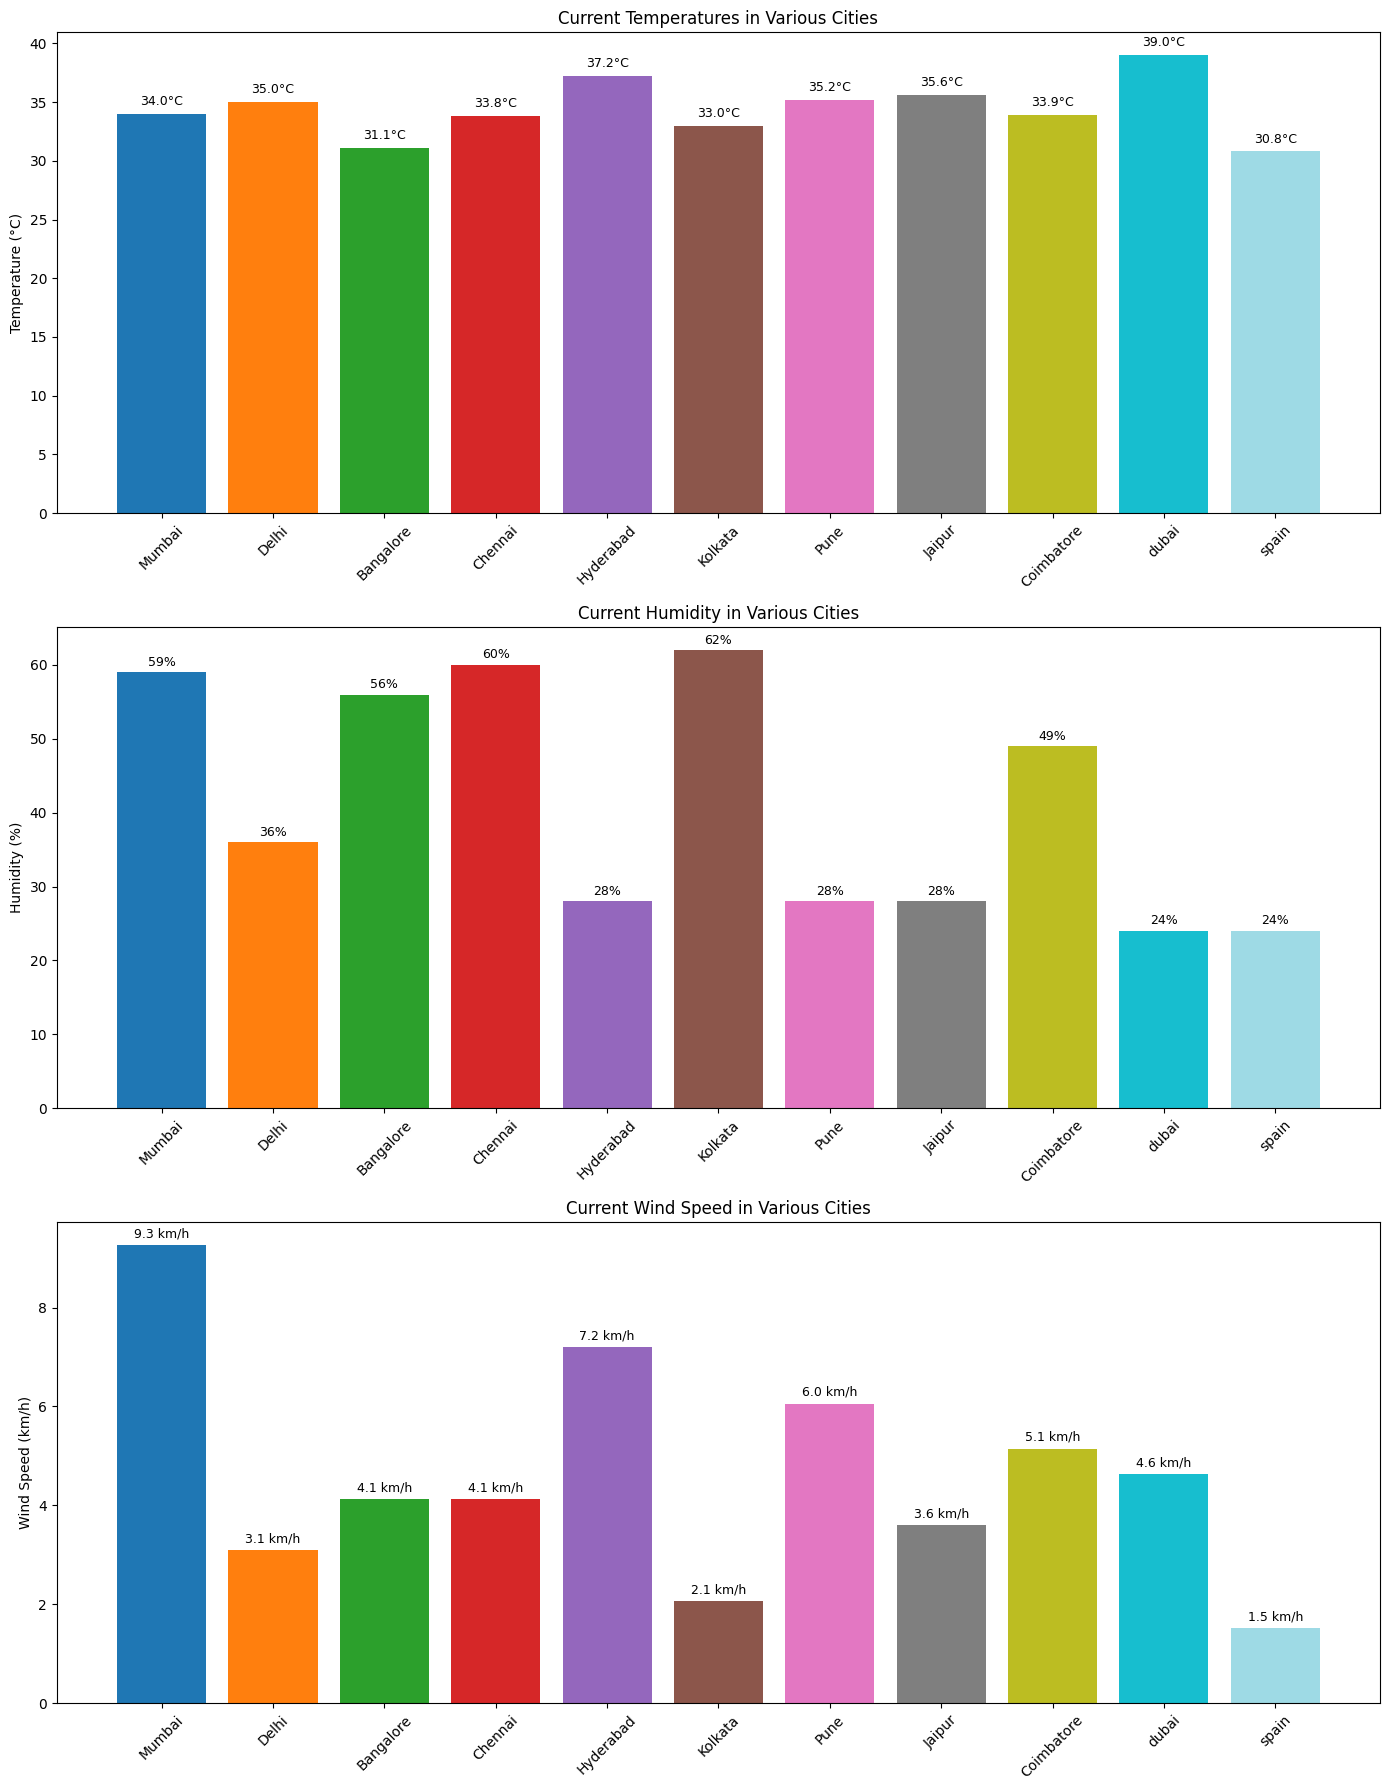


Weather Data Table:
          city  temperature  feels_like  humidity  pressure  wind_speed  \
0       Mumbai         34.0        41.0        59      1008        9.26   
1        Delhi         35.0        36.2        36      1001        3.09   
2    Bangalore         31.1        34.0        56      1007        4.12   
3      Chennai         33.8        40.8        60      1005        4.12   
4    Hyderabad         37.2        37.5        28      1006        7.20   
5      Kolkata         33.0        40.0        62      1002        2.06   
6         Pune         35.2        34.6        28      1007        6.05   
7       Jaipur         35.6        35.1        28      1005        3.60   
8   Coimbatore         33.9        37.8        49      1008        5.14   
9        dubai         39.0        39.1        24      1003        4.63   
10       spain         30.8        29.1        24      1019        1.51   

   condition  visibility  
0       Haze        6000  
1     Clouds        7000

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure df_weather is available from the previous cell's execution
# If not, create it from weather_records
# Always recreate df_weather from the latest weather_records to include newly added cities
df_weather = pd.DataFrame(weather_records)

# Extract data for plotting
cities = df_weather['city'].tolist()
temperatures = df_weather['temperature'].tolist()
humidity = df_weather['humidity'].tolist()
wind_speed = df_weather['wind_speed'].tolist()

# Define a color map for cities
# Generate a set of distinct colors, one for each city
colors = plt.cm.get_cmap('tab20', len(cities))

# Create a figure with three subplots (one for each metric)
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# --- Plot Temperature ---
axes[0].bar(cities, temperatures, color=colors(np.arange(len(cities))))
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Current Temperatures in Various Cities')
axes[0].tick_params(axis='x', rotation=45)
# Add values on top of bars
for i, temp in enumerate(temperatures):
    axes[0].text(i, temp + 0.5, f'{temp}°C', ha='center', va='bottom', fontsize=9)

# --- Plot Humidity ---
axes[1].bar(cities, humidity, color=colors(np.arange(len(cities))))
axes[1].set_ylabel('Humidity (%)')
axes[1].set_title('Current Humidity in Various Cities')
axes[1].tick_params(axis='x', rotation=45)
# Add values on top of bars
for i, hum in enumerate(humidity):
    axes[1].text(i, hum + 0.5, f'{hum}%', ha='center', va='bottom', fontsize=9)

# --- Plot Wind Speed ---
axes[2].bar(cities, wind_speed, color=colors(np.arange(len(cities))))
axes[2].set_ylabel('Wind Speed (km/h)')
axes[2].set_title('Current Wind Speed in Various Cities')
axes[2].tick_params(axis='x', rotation=45)
# Add values on top of bars
for i, ws in enumerate(wind_speed):
    axes[2].text(i, ws + 0.1, f'{ws:.1f} km/h', ha='center', va='bottom', fontsize=9)

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# Display data using pandas
print("\nWeather Data Table:")
print(df_weather[['city', 'temperature', 'feels_like', 'humidity', 'pressure', 'wind_speed', 'condition', 'visibility']])

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Ensure df_weather is available. If not, rerun the previous cell to generate it.
if 'df_weather' not in locals():
    print("df_weather not found. Please run the previous cell to fetch weather data first.")
else:
    # Prepare the data for prediction
    # Features (X) are 'temperature' and 'wind_speed'
    # Target (y) is 'humidity'
    X = df_weather[['temperature', 'wind_speed']]
    y = df_weather['humidity']

    # Split the data into training and testing sets
    # Using a test size of 20% and a random state for reproducibility
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize the Linear Regression model
    model = LinearRegression()

    # Train the model using the training data
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\nLinear Regression Model Performance:")
    print(f"Coefficients: {model.coef_}") # Coefficients for temperature and wind_speed
    print(f"Intercept: {model.intercept_}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared (R2) Score: {r2:.2f}")

    # Display actual vs. predicted values for a few test samples
    results_df = pd.DataFrame({'Actual Humidity': y_test, 'Predicted Humidity': y_pred})
    print("\nActual vs. Predicted Humidity (first 5 test samples):\n", results_df.head())

    print("\nModel trained and evaluated successfully.")
    print("Interpretation: The coefficients indicate how much humidity changes for a one-unit increase in temperature or wind speed, respectively, holding other factors constant. MAE represents the average absolute difference between actual and predicted values. R-squared indicates the proportion of variance in the dependent variable that can be predicted from the independent variables.")


Linear Regression Model Performance:
Coefficients: [-5.69341416  0.4347276 ]
Intercept: 239.02397624448258
Mean Absolute Error (MAE): 2.92
R-squared (R2) Score: 0.69

Actual vs. Predicted Humidity (first 5 test samples):
    Actual Humidity  Predicted Humidity
8               49           48.251736
1               36           41.097789

Model trained and evaluated successfully.
Interpretation: The coefficients indicate how much humidity changes for a one-unit increase in temperature or wind speed, respectively, holding other factors constant. MAE represents the average absolute difference between actual and predicted values. R-squared indicates the proportion of variance in the dependent variable that can be predicted from the independent variables.
